In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("data/raw/accidents_2019_2023.csv")

C:\Users\fatis\AppData\Local\Temp\ipykernel_5836\2471230182.py:1: DtypeWarning: Columns (42,45,48,49) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/raw/accidents_2019_2023.csv")


In [3]:
print("Dimensions du dataset :", df.shape)
display(df.head())

Dimensions du dataset : (657865, 54)


,Num_Acc,id_vehicule,num_veh,senc,catv,obs,obsm,choc,manv,motor,...,prof,pr,pr1,plan,lartpc,larrout,surf,infra,situ,vma
0,201900000001,138 306 524,B01,2,7,0,2,5,23,1,...,1,6,900,2,NaN,NaN,1,2,1,70
1,201900000001,138 306 524,B01,2,7,0,2,5,23,1,...,1,6,900,2,NaN,NaN,1,2,1,70
2,201900000001,138 306 525,A01,2,17,1,0,3,11,1,...,1,6,900,2,NaN,NaN,1,2,1,70
3,201900000002,138 306 523,A01,1,7,4,0,1,0,1,...,4,3,845,2,NaN,NaN,1,0,1,70
4,201900000003,138 306 520,A01,1,7,0,2,1,2,1,...,1,10,500,3,NaN,NaN,1,0,1,90


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 657865 entries, 0 to 657864
Data columns (total 54 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Num_Acc      657865 non-null  int64  
 1   id_vehicule  657865 non-null  object 
 2   num_veh      657865 non-null  object 
 3   senc         657865 non-null  int64  
 4   catv         657865 non-null  int64  
 5   obs          657865 non-null  int64  
 6   obsm         657865 non-null  int64  
 7   choc         657865 non-null  int64  
 8   manv         657865 non-null  int64  
 9   motor        657865 non-null  int64  
 10  occutc       8938 non-null    float64
 11  place        657865 non-null  int64  
 12  catu         657865 non-null  int64  
 13  grav         657865 non-null  int64  
 14  sexe         657865 non-null  int64  
 15  an_nais      648412 non-null  float64
 16  trajet       657865 non-null  int64  
 17  secu1        657865 non-null  int64  
 18  secu2        657865 non-

In [5]:
df.describe(include=[np.number])

,Num_Acc,senc,catv,obs,obsm,choc,manv,motor,occutc,place,...,catr,v1,circ,vosp,prof,plan,surf,infra,situ,vma
count,6.578650e+05,657865.000000,657865.000000,657865.000000,657865.000000,657865.000000,657865.000000,657865.000000,8938.000000,657865.000000,...,657865.000000,633269.000000,657865.000000,657865.000000,657865.000000,657865.000000,657865.000000,657865.000000,657865.000000,657865.000000
mean,2.021126e+11,1.568614,12.720155,1.102202,1.583977,2.873802,7.067578,1.229524,6.776236,2.093238,...,3.303587,-0.155135,1.810692,0.184752,1.226843,1.278802,1.253792,0.812632,1.477238,59.254358
std,1.463055e+08,0.827607,13.488152,3.230166,1.192413,2.396278,8.014907,1.050140,11.086558,2.591587,...,1.256788,0.382831,0.912122,0.670684,0.545919,0.660801,0.784540,2.164946,1.429355,26.026253
min,2.019000e+11,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.000000,-1.000000,...,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,2.020000e+11,1.000000,7.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,3.000000,0.000000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,50.000000
50%,2.021000e+11,1.000000,7.000000,0.000000,2.000000,2.000000,2.000000,1.000000,2.000000,1.000000,...,3.000000,0.000000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,50.000000
75%,2.022001e+11,2.000000,10.000000,0.000000,2.000000,4.000000,15.000000,1.000000,6.000000,2.000000,...,4.000000,0.000000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,80.000000
max,2.023001e+11,3.000000,99.000000,17.000000,9.000000,9.000000,26.000000,6.000000,65.000000,10.000000,...,9.000000,3.000000,4.000000,3.000000,4.000000,4.000000,9.000000,9.000000,8.000000,901.000000


In [6]:
# Remplacement de toutes les valeurs -1 par NaN
df.replace(-1, np.nan, inplace=True)

In [7]:
df.isna().sum().sort_values(ascending=False).head(10)

lartpc     656705
secu3      649192
occutc     648927
etatp      607046
v2         604700
locp       302413
secu2      263552
larrout    132146
v1         125912
voie        75960
dtype: int64

In [8]:
# Suppression des colonnes avec plus de 90% de valeurs manquantes
seuil = 0.9  # 90%
nb_lignes = len(df)
colonnes_a_supprimer = [col for col in df.columns if df[col].isna().sum() / nb_lignes > seuil]

print("Colonnes supprimées :", colonnes_a_supprimer)
df.drop(columns=colonnes_a_supprimer, inplace=True)

Colonnes supprimées : ['occutc', 'secu3', 'etatp', 'v2', 'lartpc']


In [9]:
# Suppression des doublons 
print("Nombre de doublons :", df.duplicated().sum())
df.drop_duplicates(inplace=True)

Nombre de doublons : 632


In [10]:
# Création d'une colonne 'date' à partir de jour/mois/an
df['date'] = pd.to_datetime(dict(year=df['an'], month=df['mois'], day=df['jour']), errors='coerce')

# Création du jour de la semaine
df['jour_semaine'] = df['date'].dt.dayofweek  

# Extraction de l'heure depuis la colonne 'hrmn' s
def extraire_heure(chaine):
    try:
        return int(str(chaine).split(':')[0])
    except:
        return np.nan

df['heure'] = df['hrmn'].apply(extraire_heure)

In [11]:
# Liste des colonnes catégorielles à encoder
colonnes_label = ['lum', 'agg', 'catr', 'atm', 'col', 'plan', 'surf', 'infra', 'situ']

# Encodage LabelEncoder
for col in colonnes_label:
    df[col] = df[col].astype('category').cat.codes

In [12]:
# Création d'une variable âge
df['age'] = 2023 - df['an_nais']


In [13]:
# Vérification des âges aberrants
print("Âges aberrants (négatifs ou > 100 ans) :", df[df['age'] < 0].shape[0], "/", df[df['age'] > 100].shape[0])

Âges aberrants (négatifs ou > 100 ans) : 0 / 255


In [14]:
# Correction des âges aberrants
df.loc[(df['age'] < 0) | (df['age'] > 100), 'age'] = np.nan

In [15]:
# Vérification des vitesses maximales autorisées (vma)
print("Valeurs de VMA supérieures à 150 :", df[df['vma'] > 150].shape[0])

Valeurs de VMA supérieures à 150 : 152


In [16]:
# Colonnes avec une seule valeur unique
colonnes_uniques = [col for col in df.columns if df[col].nunique() <= 1]
print("Colonnes peu informatives :", colonnes_uniques)

Colonnes peu informatives : []


In [17]:
colonnes_inutiles = ['Num_Acc', 'id_vehicule', 'voie', 'v1', 'v2', 'pr', 'pr1', 'adr', 'hrmn', 'an_nais', 'date']

df.drop(columns=[col for col in colonnes_inutiles if col in df.columns], inplace=True)

In [18]:
# Regroupement des valeurs rares dans 'catv'
frequentes = df['catv'].value_counts()
valeurs_rares = frequentes[frequentes < 100].index

df['catv'] = df['catv'].apply(lambda x: 'autre' if x in valeurs_rares else x)

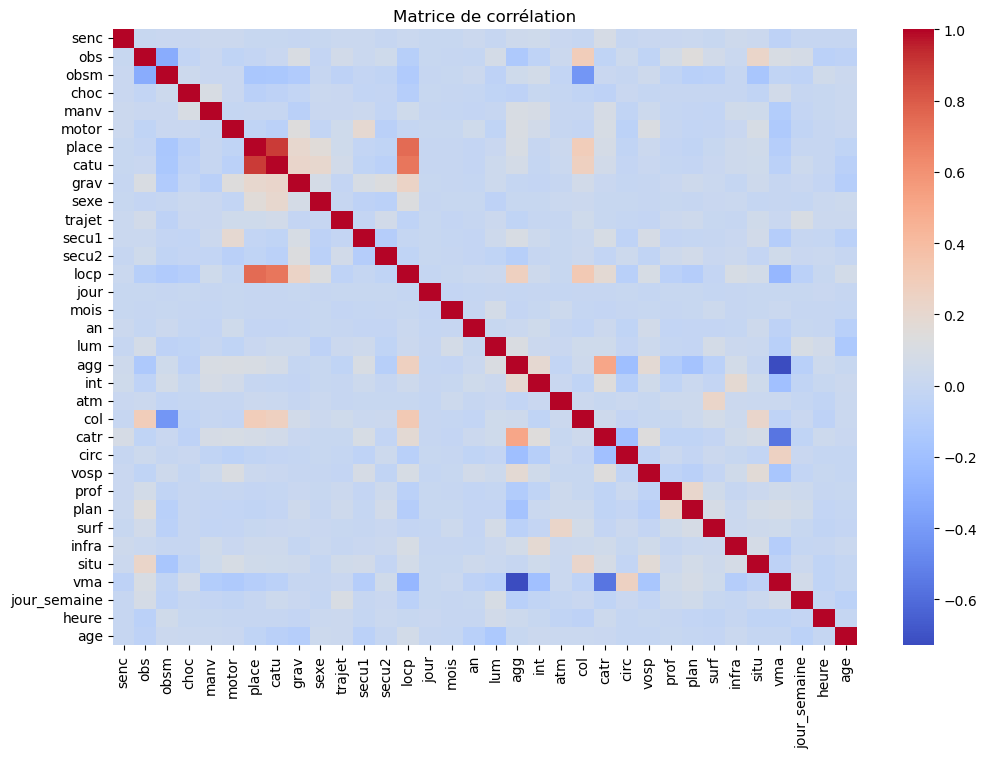

In [19]:
# Vérification de la corrélation entre variables

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=False, cmap="coolwarm")
plt.title("Matrice de corrélation")
plt.show()

In [20]:
# on supprime grav du dataset
y = df['grav']
X = df.drop(columns=['grav'])
print("Shape de X :", X.shape)
print("Shape de y :", y.shape)

Shape de X : (657233, 42)
Shape de y : (657233,)
